# 02 — Exploratory Data Analysis

Exploratory analysis of the cleaned, combined cardiovascular dataset (`combined_clean.csv`, produced by
[`01_data_cleaning.ipynb`](01_data_cleaning.ipynb) / [`dataset.py`](../dataset.py)) — 88,202 records across two
regional cohorts (Russia, China).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE = os.path.join(os.getcwd(), "..")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(os.path.join(BASE, "combined_clean.csv"))
print(df.shape)
df.head()


(88202, 18)


,age,gender,height,weight,bmi,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,source,cholesterol_mgdl,gluc_mgdl,cholesterol_label,gluc_label
0,50,2,168,62.0,21.967120,110,80,1,1,0,0,1,0,russia,180,90,Normal (<200),Normal (<100)
1,55,1,156,85.0,34.927679,140,90,3,1,0,0,1,1,russia,270,90,Well Above Normal (≥240),Normal (<100)
2,52,1,165,64.0,23.507805,130,70,3,1,0,0,0,1,russia,270,90,Well Above Normal (≥240),Normal (<100)
3,48,2,169,82.0,28.710479,150,100,1,1,0,0,1,1,russia,180,90,Normal (<200),Normal (<100)
4,48,1,156,56.0,23.011177,100,60,1,1,0,0,0,0,russia,180,90,Normal (<200),Normal (<100)


## 1. Target class balance

cardio
0    0.504977
1    0.495023
Name: proportion, dtype: float64


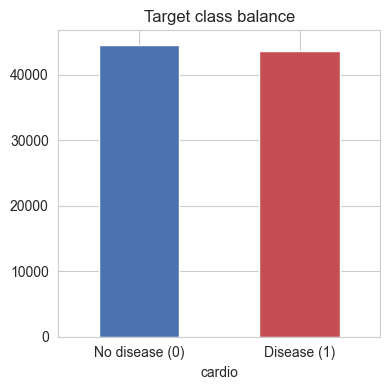

In [2]:
print(df["cardio"].value_counts(normalize=True).rename("proportion"))
fig, ax = plt.subplots(figsize=(4,4))
df["cardio"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4c72b0","#c44e52"])
ax.set_xticklabels(["No disease (0)", "Disease (1)"], rotation=0)
ax.set_title("Target class balance")
plt.tight_layout()
plt.show()


**Observation:** the target is almost perfectly balanced (~50/50). This matters for evaluation — it means a
model that just predicts the majority class would score ~50% accuracy, so any accuracy meaningfully above that
reflects real signal, and metrics like accuracy aren't misleading the way they would be on an imbalanced set.

## 2. Summary statistics by class

In [3]:
df.groupby("cardio")[["age","bmi","ap_hi","ap_lo","cholesterol","gluc"]].mean().round(2)


,age,bmi,ap_hi,ap_lo,cholesterol,gluc
cardio,,,,,,
0,51.72,26.45,119.62,78.12,1.22,1.17
1,54.97,28.45,133.86,84.54,1.52,1.28


## 3. Age distribution by disease status

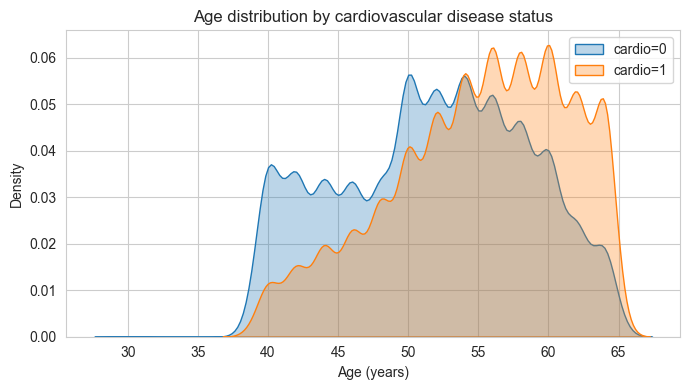

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
for label, group in df.groupby("cardio"):
    sns.kdeplot(group["age"], ax=ax, label=f"cardio={label}", fill=True, alpha=0.3)
ax.set_title("Age distribution by cardiovascular disease status")
ax.set_xlabel("Age (years)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Blood pressure vs. BMI, colored by disease status

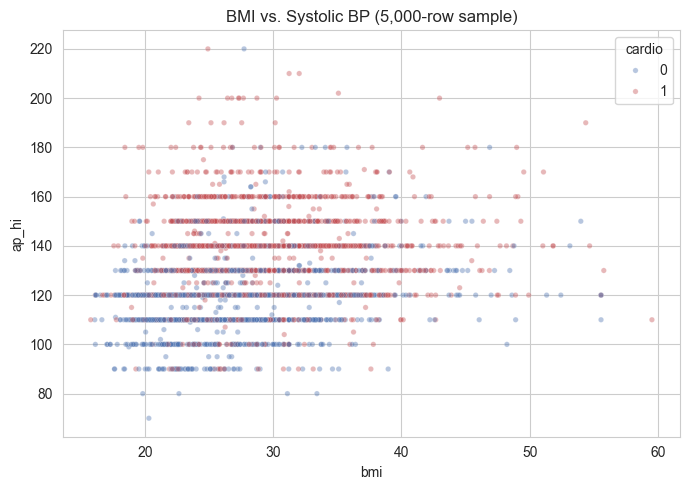

In [5]:
fig, ax = plt.subplots(figsize=(7,5))
sample = df.sample(n=5000, random_state=42)
sns.scatterplot(data=sample, x="bmi", y="ap_hi", hue="cardio", alpha=0.4, s=15, ax=ax, palette=["#4c72b0","#c44e52"])
ax.set_title("BMI vs. Systolic BP (5,000-row sample)")
plt.tight_layout()
plt.show()


## 5. Cholesterol and glucose category vs. disease prevalence

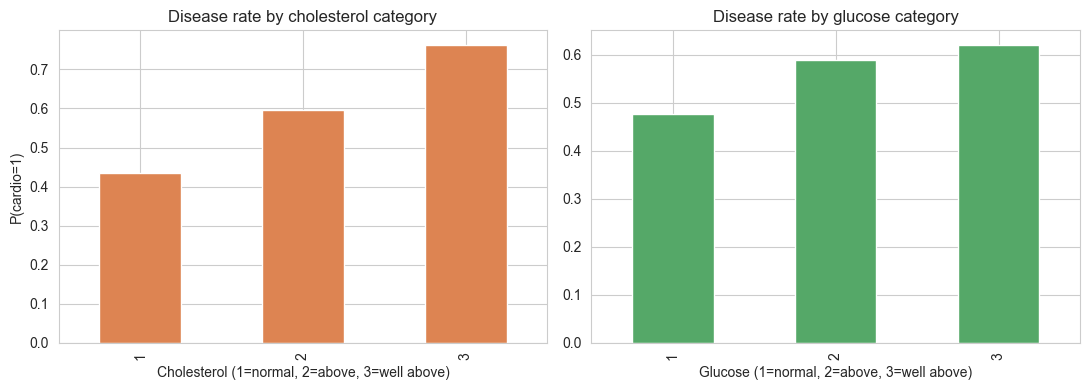

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df.groupby("cholesterol")["cardio"].mean().plot(kind="bar", ax=axes[0], color="#dd8452")
axes[0].set_title("Disease rate by cholesterol category")
axes[0].set_xlabel("Cholesterol (1=normal, 2=above, 3=well above)")
axes[0].set_ylabel("P(cardio=1)")

df.groupby("gluc")["cardio"].mean().plot(kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("Disease rate by glucose category")
axes[1].set_xlabel("Glucose (1=normal, 2=above, 3=well above)")
plt.tight_layout()
plt.show()


## 6. Lifestyle factors: smoking, alcohol, physical activity

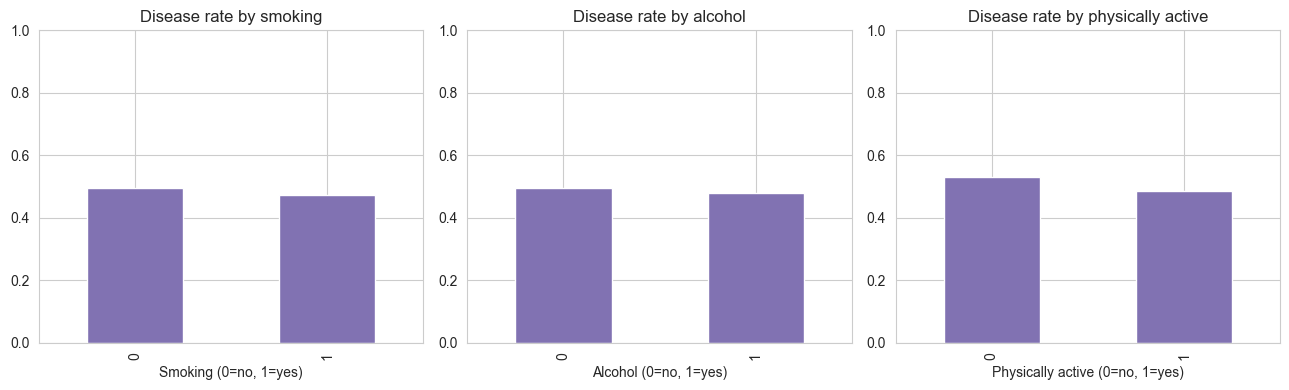

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, col, title in zip(axes, ["smoke","alco","active"], ["Smoking","Alcohol","Physically active"]):
    rates = df.groupby(col)["cardio"].mean()
    rates.plot(kind="bar", ax=ax, color="#8172b2")
    ax.set_title(f"Disease rate by {title.lower()}")
    ax.set_xlabel(f"{title} (0=no, 1=yes)")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Observation:** the raw univariate lifestyle effects (smoking, alcohol, activity) are notably weaker/noisier
predictors than clinical measurements (blood pressure, cholesterol, age) in this dataset — consistent with the
feature-importance ranking produced by the trained model in
[`03_model_comparison.ipynb`](03_model_comparison.ipynb). This is a known property of this Kaggle dataset and is
worth stating plainly rather than implying lifestyle factors don't matter clinically — self-reported, binary
lifestyle flags carry far less information than a measured systolic BP reading.

## 7. Correlation matrix

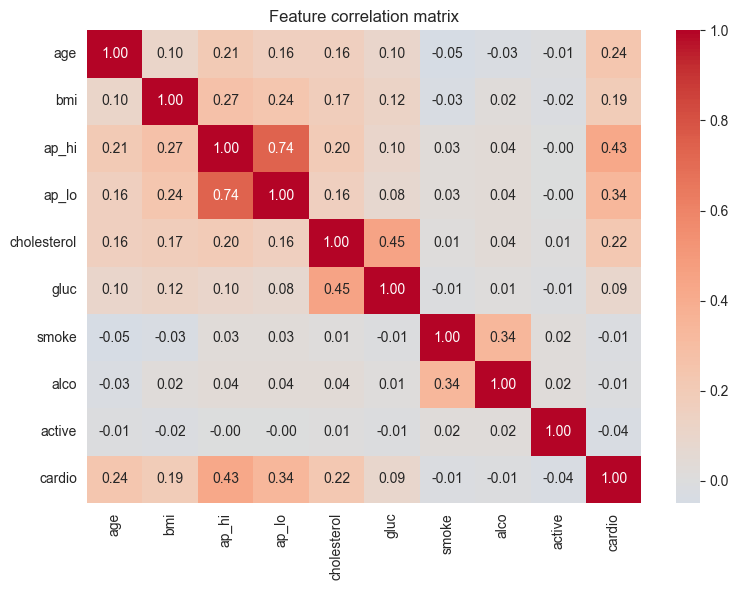

In [8]:
num_cols = ["age","bmi","ap_hi","ap_lo","cholesterol","gluc","smoke","alco","active","cardio"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()


## 8. Regional comparison (Russia vs. China cohort)

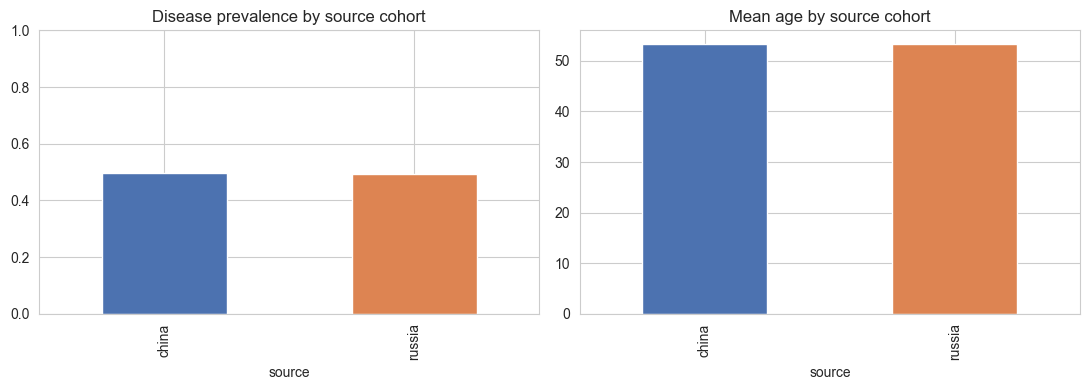

,age,bmi,ap_hi,ap_lo,cardio
source,,,,,
china,53.35,27.43,126.68,81.3,0.50
russia,53.33,27.45,126.67,81.3,0.49


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df.groupby("source")["cardio"].mean().plot(kind="bar", ax=axes[0], color=["#4c72b0","#dd8452"])
axes[0].set_title("Disease prevalence by source cohort")
axes[0].set_ylim(0,1)

df.groupby("source")["age"].mean().plot(kind="bar", ax=axes[1], color=["#4c72b0","#dd8452"])
axes[1].set_title("Mean age by source cohort")
plt.tight_layout()
plt.show()

df.groupby("source")[["age","bmi","ap_hi","ap_lo","cardio"]].mean().round(2)


**Observation:** the two source cohorts are, on average, nearly identical in age, BMI, blood pressure, and
disease prevalence (all within ~0.02 of each other) — likely a property of how the Shanxi dataset was assembled
rather than evidence the pooling is safe in general. Aggregate similarity does not rule out per-cohort performance
differences once the model is trained (e.g. different feature interactions per population), so per-cohort accuracy
is still checked explicitly in [`../docs/BIAS_AND_LIMITATIONS.md`](../docs/BIAS_AND_LIMITATIONS.md) rather than
assumed safe from these summary stats alone.

## Summary of findings

- Target class is balanced (~50/50), so accuracy is a fair top-line metric and no resampling is required.
- `ap_hi` (systolic BP), `age`, `cholesterol`, and `bmi` show the clearest separation between disease/no-disease
  groups — consistent with established cardiovascular risk factors.
- Binary lifestyle self-reports (smoking, alcohol, activity) show weak, sometimes counter-intuitive univariate
  relationships with the target, most likely reflecting self-report bias and the confound that already-diagnosed
  patients may have changed behavior (e.g. quit smoking) after diagnosis.
- The two source cohorts (Russia, China) are nearly identical in aggregate summary statistics, but per-cohort
  model performance is still checked explicitly rather than assumed — see the bias/limitations write-up.
